# Initial Data Exploration — Uber NCR Ride Bookings

**Dataset:** `ncr_ride_bookings.csv`  
**Source:** Kaggle — `yashdevladdha/uber-ride-analytics-dashboard`  
**Rows:** 150,000 | **Columns:** 21

---

## How to download this dataset from Kaggle

**Option A — Terminal (recommended)**
```bash
# from experiment_1/
uv run kaggle datasets download yashdevladdha/uber-ride-analytics-dashboard --unzip -p data/
```

**Credentials** — Kaggle reads from either:
- `~/.kaggle/kaggle.json` → `{"username": "...", "key": "..."}`
- Env var → `export KAGGLE_API_TOKEN=your_token`

In [23]:
import sys
import os
sys.path.insert(0, os.path.abspath('../../..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
from pathlib import Path
from utils.analysis_log import AnalysisLog

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.2f}'.format)

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

log = AnalysisLog()
log.add(
    section_id='01_setup',
    title='Setup',
    cell_type='setup',
    purpose='Load libraries, initialize AnalysisLog, and create output directory',
    data={
        'libraries': ['pandas', 'numpy', 'matplotlib', 'seaborn', 'json', 'pathlib'],
        'output_dir': str(OUTPUT_DIR),
    },
)

## 1. Load Data

In [24]:
DATA_PATH = Path('..') / 'data' / 'ncr_ride_bookings.csv'
df = pd.read_csv(DATA_PATH)

log.add(
    section_id='02_load_data',
    title='Load Data',
    cell_type='setup',
    purpose='Read the Uber NCR ride bookings CSV into a DataFrame',
    data={'dataset': 'ncr_ride_bookings.csv', 'rows': df.shape[0], 'columns': df.shape[1]},
)
df.shape

(150000, 21)

In [25]:
log.add(
    section_id='03_data_preview',
    title='Data Preview',
    cell_type='analysis',
    purpose='Display the first few rows to verify data loaded correctly and inspect column values',
    data={'head': df.head().to_dict(orient='records')},
)
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.90,14.00,...,NaN,NaN,NaN,1.00,Vehicle Breakdown,237.00,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.40,25.80,...,NaN,NaN,NaN,NaN,NaN,627.00,13.58,4.90,4.90,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.10,28.50,...,NaN,NaN,NaN,NaN,NaN,416.00,34.02,4.60,5.00,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.30,19.60,...,NaN,NaN,NaN,NaN,NaN,737.00,48.21,4.10,4.30,UPI


## 2. Schema & Dtypes

In [26]:
schema = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null_%': (df.isnull().mean() * 100).round(1),
    'nunique': df.nunique(),
})

log.add(
    section_id='04_schema_dtypes',
    title='Schema & Dtypes',
    cell_type='analysis',
    purpose='Inspect column names, data types, null counts, and cardinality',
    data=schema.assign(dtype=schema['dtype'].astype(str)).to_dict(orient='index'),
)
schema

,dtype,non_null,null_%,nunique
Date,str,150000,0.00,365
Time,str,150000,0.00,62910
Booking ID,str,150000,0.00,148767
Booking Status,str,150000,0.00,5
Customer ID,str,150000,0.00,148788
Vehicle Type,str,150000,0.00,7
Pickup Location,str,150000,0.00,176
Drop Location,str,150000,0.00,176
Avg VTAT,float64,139500,7.00,181
Avg CTAT,float64,102000,32.00,351


## 3. Missing Values

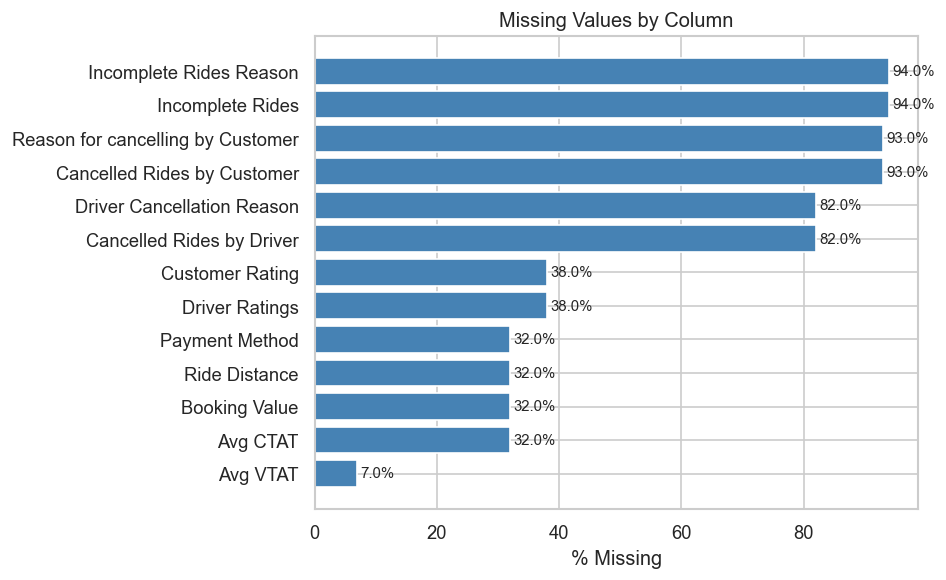

In [27]:
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(1)
missing = pd.DataFrame({'null_count': nulls, 'null_%': null_pct})
missing_nonzero = missing[missing.null_count > 0].sort_values('null_%', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(missing_nonzero.index, missing_nonzero['null_%'], color='steelblue')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column')
for i, v in enumerate(missing_nonzero['null_%']):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

log.add(
    section_id='05_missing_values',
    title='Missing Values',
    cell_type='analysis',
    purpose='Identify columns with missing data and their null percentages',
    data=missing_nonzero.to_dict(orient='index'),
)

## 4. Booking Status

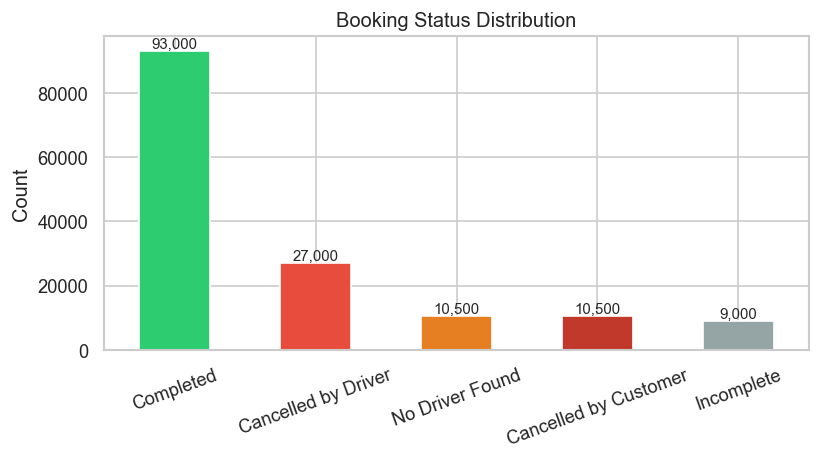

In [28]:
status_counts = df['Booking Status'].value_counts()
status_pct = (status_counts / len(df) * 100).round(1)
status_df = pd.DataFrame({'count': status_counts, '%': status_pct})

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71', '#e74c3c', '#e67e22', '#c0392b', '#95a5a6']
status_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Booking Status Distribution')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

log.add(
    section_id='06_booking_status',
    title='Booking Status Distribution',
    cell_type='analysis',
    purpose='Show the frequency and percentage of each booking status category',
    data=status_df.to_dict(orient='index'),
)

## 5. Vehicle Type

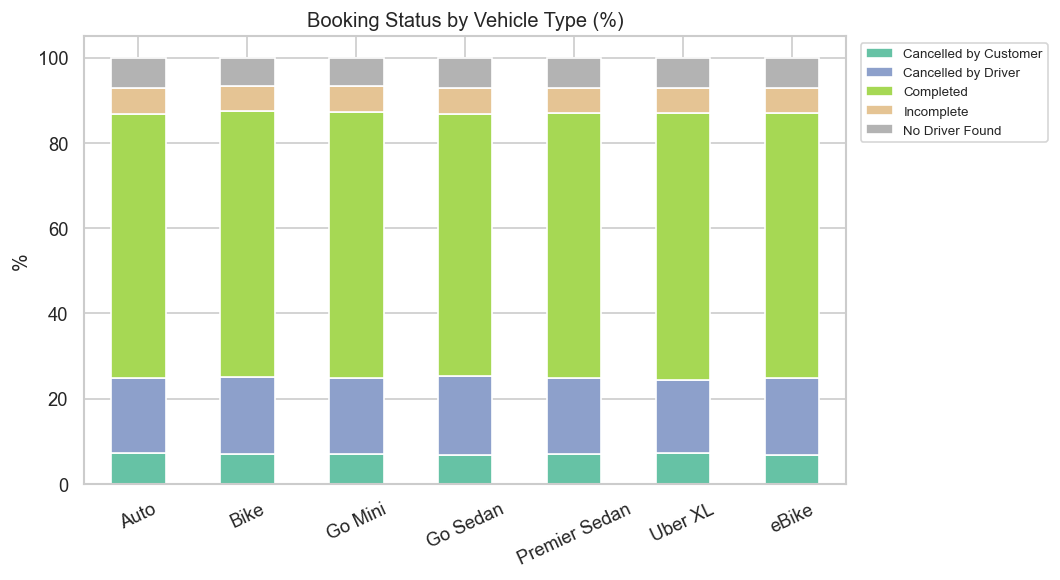

In [29]:
vehicle_ct = pd.crosstab(df['Vehicle Type'], df['Booking Status'], normalize='index') * 100
vehicle_ct.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='Set2', edgecolor='white')
plt.title('Booking Status by Vehicle Type (%)')
plt.xlabel('')
plt.ylabel('%')
plt.xticks(rotation=25)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

log.add(
    section_id='07_vehicle_type',
    title='Vehicle Type by Booking Status',
    cell_type='analysis',
    purpose='Analyze booking status breakdown across vehicle types as a percentage crosstab',
    data=vehicle_ct.round(1).to_dict(orient='index'),
)

## 6. Numeric Distributions

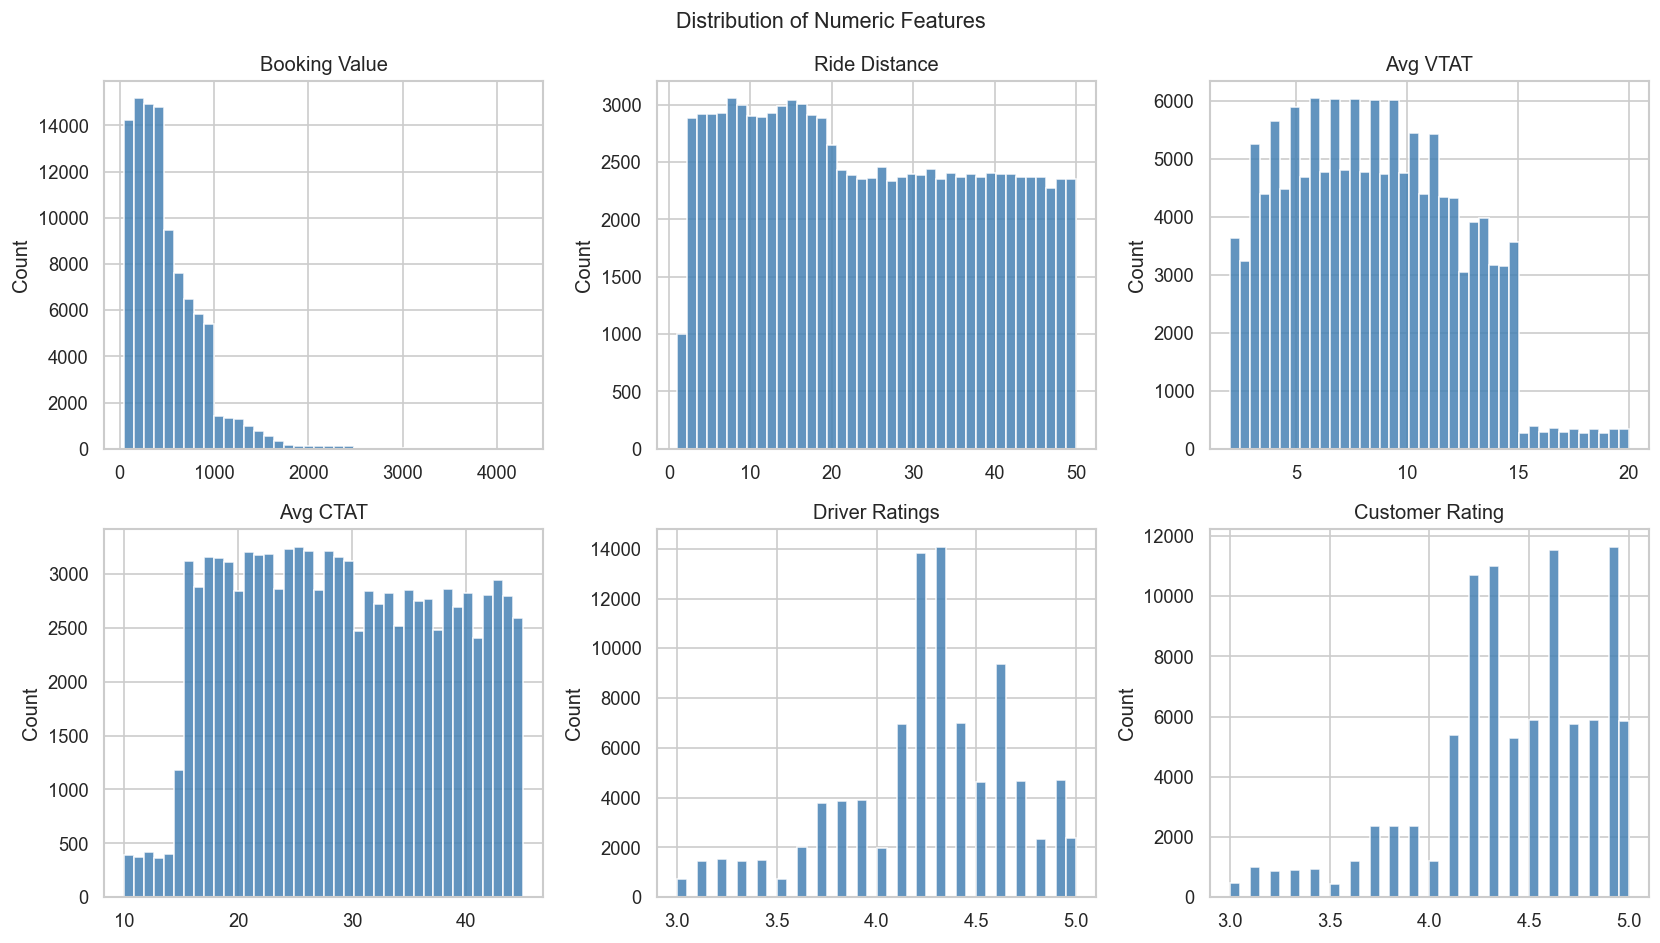

In [30]:
numeric_cols = ['Booking Value', 'Ride Distance', 'Avg VTAT', 'Avg CTAT', 'Driver Ratings', 'Customer Rating']
numeric_summary = df[numeric_cols].describe().T

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

log.add(
    section_id='08_numeric_distributions',
    title='Numeric Distributions',
    cell_type='analysis',
    purpose='Compute descriptive statistics and visualize distributions of all numeric features',
    data=numeric_summary.to_dict(orient='index'),
)

## 7. Ratings (Completed Rides Only)

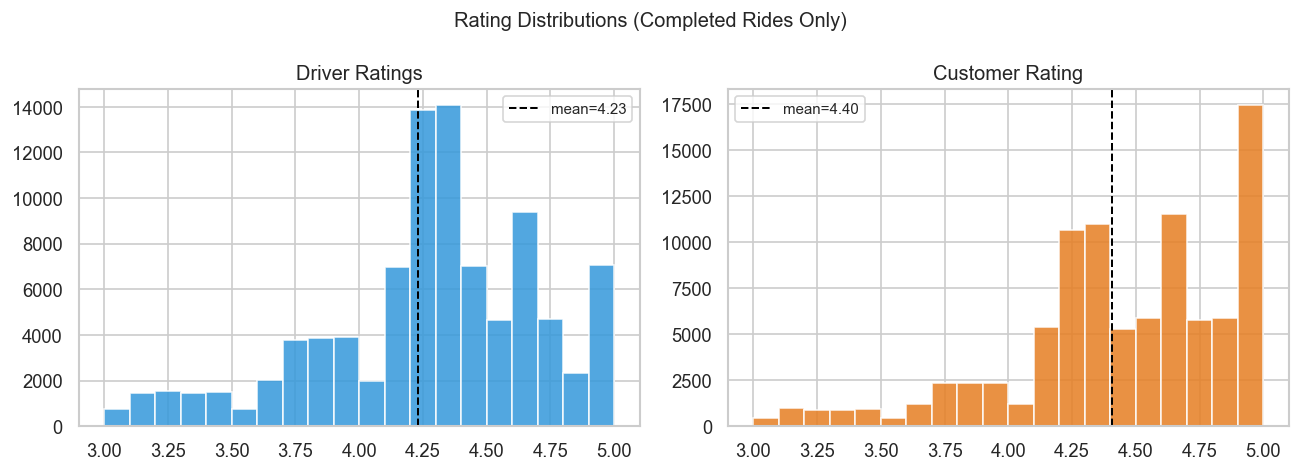

In [31]:
completed = df[df['Booking Status'] == 'Completed'].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, color in zip(axes,
                          ['Driver Ratings', 'Customer Rating'],
                          ['#3498db', '#e67e22']):
    ax.hist(completed[col].dropna(), bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(completed[col].mean(), color='black', linestyle='--',
               linewidth=1.2, label=f"mean={completed[col].mean():.2f}")
    ax.set_title(col)
    ax.legend(fontsize=9)
plt.suptitle('Rating Distributions (Completed Rides Only)', fontsize=12)
plt.tight_layout()
plt.show()

ratings_summary = {
    col: {'mean': round(completed[col].mean(), 3),
          'median': round(completed[col].median(), 3),
          'std': round(completed[col].std(), 3)}
    for col in ['Driver Ratings', 'Customer Rating']
}

log.add(
    section_id='09_ratings',
    title='Ratings (Completed Rides Only)',
    cell_type='analysis',
    purpose='Analyze driver and customer rating distributions for completed rides',
    data=ratings_summary,
)

## 8. Cancellation Reasons

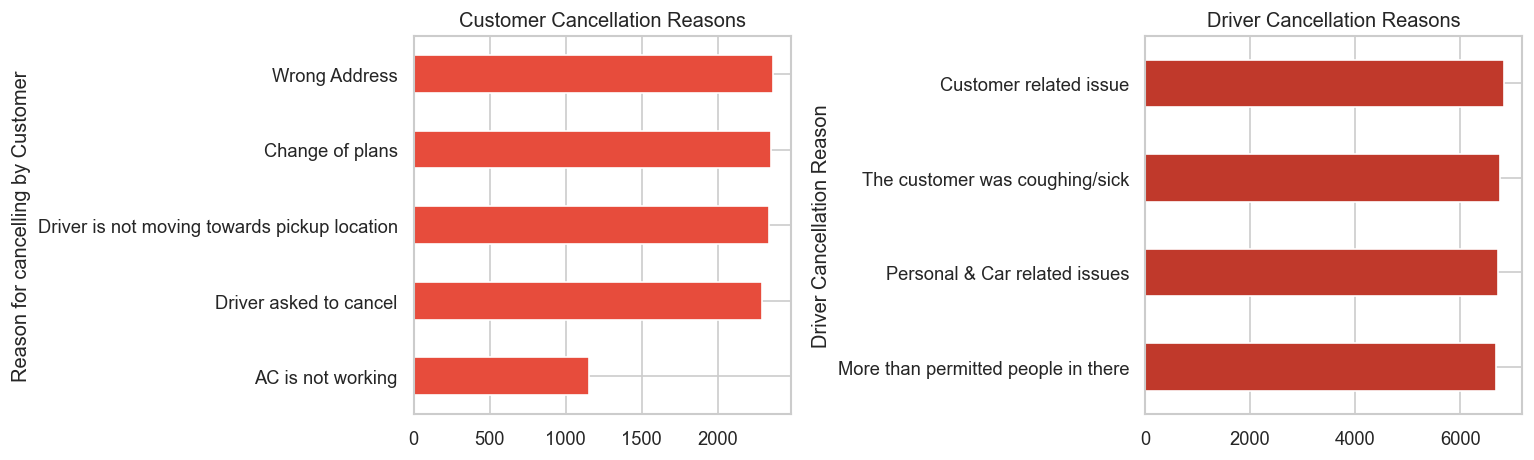

In [32]:
customer_reasons = df['Reason for cancelling by Customer'].value_counts()
driver_reasons = df['Driver Cancellation Reason'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
customer_reasons.plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='white')
axes[0].set_title('Customer Cancellation Reasons')
axes[0].invert_yaxis()
driver_reasons.plot(kind='barh', ax=axes[1], color='#c0392b', edgecolor='white')
axes[1].set_title('Driver Cancellation Reasons')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

log.add(
    section_id='10_cancellation_reasons',
    title='Cancellation Reasons',
    cell_type='analysis',
    purpose='Identify the most common reasons customers and drivers cancel rides',
    data={
        'customer': customer_reasons.to_dict(),
        'driver': driver_reasons.to_dict(),
    },
)

## 9. Payment Method

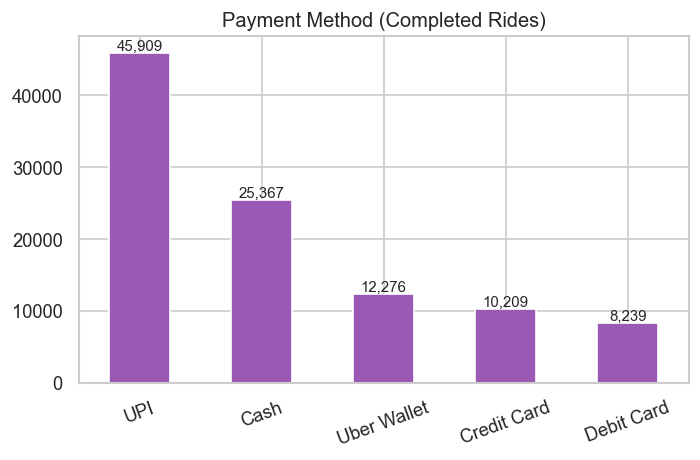

In [33]:
payment = df['Payment Method'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
payment.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title('Payment Method (Completed Rides)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

log.add(
    section_id='11_payment_method',
    title='Payment Method Distribution',
    cell_type='analysis',
    purpose='Show the breakdown of payment methods used in completed rides',
    data=payment.to_dict(),
)

## 10. ID Quality & Duplicates

Booking ID and Customer ID are read as strings. Checking whether IDs are clean
and whether Booking IDs are truly unique (they should be, as a primary key).

In [34]:
id_quality = pd.DataFrame({
    'column': ['Booking ID', 'Customer ID'],
    'total_rows': [len(df), len(df)],
    'unique': [df['Booking ID'].nunique(), df['Customer ID'].nunique()],
    'duplicates': [df['Booking ID'].duplicated().sum(), df['Customer ID'].duplicated().sum()],
    'sample_raw_value': [df['Booking ID'].iloc[0], df['Customer ID'].iloc[0]],
})

log.add(
    section_id='12_id_quality',
    title='ID Quality',
    cell_type='analysis',
    purpose='Check uniqueness and duplication of Booking ID and Customer ID columns',
    data=id_quality.to_dict(orient='records'),
)
id_quality

,column,total_rows,unique,duplicates,sample_raw_value
0,Booking ID,150000,148767,1233,"""CNR5884300"""
1,Customer ID,150000,148788,1212,"""CID1982111"""


In [35]:
dup_ids = df[df['Booking ID'].duplicated(keep=False)].sort_values('Booking ID')
sample = dup_ids[['Booking ID', 'Date', 'Time', 'Booking Status', 'Customer ID', 'Vehicle Type']].head(10)

log.add(
    section_id='13_duplicate_booking_ids',
    title='Duplicated Booking IDs Sample',
    cell_type='analysis',
    purpose='Inspect rows with duplicated Booking IDs to understand whether duplicates are identical or have differing fields',
    data={
        'duplicate_booking_id_count': int(df['Booking ID'].duplicated(keep=False).sum()),
        'sample': sample.to_dict(orient='records'),
    },
)
sample

,Booking ID,Date,Time,Booking Status,Customer ID,Vehicle Type
81334,"""CNR1026036""",2024-10-15,18:17:23,Completed,"""CID6480133""",Go Mini
9192,"""CNR1026036""",2024-07-21,17:59:41,No Driver Found,"""CID6974869""",Go Mini
9587,"""CNR1029172""",2024-12-17,19:19:02,Completed,"""CID6382731""",Auto
1353,"""CNR1029172""",2024-01-19,17:00:57,Incomplete,"""CID2615731""",Bike
82029,"""CNR1051228""",2024-11-05,16:50:20,Completed,"""CID3177617""",Auto
110412,"""CNR1051228""",2024-01-31,08:42:04,Completed,"""CID5242056""",Premier Sedan
87333,"""CNR1056023""",2024-04-20,23:16:21,Completed,"""CID9367665""",Premier Sedan
120008,"""CNR1056023""",2024-07-07,17:18:49,Incomplete,"""CID4890470""",Go Sedan
71570,"""CNR1058956""",2024-02-12,19:02:47,Cancelled by Customer,"""CID2451799""",Premier Sedan
38548,"""CNR1058956""",2024-10-15,13:33:55,Completed,"""CID1882606""",Go Mini


## 11. Structural Null Pattern by Booking Status

Nulls in this dataset are **not random missing data** — they are by design.
Columns like `Booking Value`, `Ride Distance`, `Payment Method`, and ratings
only exist once a driver has been matched and the ride has started.

In [36]:
key_cols = ['Booking Value', 'Ride Distance', 'Avg CTAT', 'Driver Ratings', 'Customer Rating', 'Payment Method']
null_by_status = (
    df.groupby('Booking Status')[key_cols]
    .apply(lambda x: (x.isnull().mean() * 100).round(0).astype(int))
)

log.add(
    section_id='14_null_pattern_by_status',
    title='Null Pattern by Booking Status',
    cell_type='analysis',
    purpose='Show that nulls are structural and status-dependent, not random missing data',
    data=null_by_status.to_dict(orient='index'),
)
null_by_status

,Booking Value,Ride Distance,Avg CTAT,Driver Ratings,Customer Rating,Payment Method
Booking Status,,,,,,
Cancelled by Customer,100,100,100,100,100,100
Cancelled by Driver,100,100,100,100,100,100
Completed,0,0,0,0,0,0
Incomplete,0,0,0,100,100,0
No Driver Found,100,100,100,100,100,100


## 12. Flag Columns — Redundant with Booking Status

`Cancelled Rides by Customer`, `Cancelled Rides by Driver`, and `Incomplete Rides`
look like numeric columns but each only ever holds the value `1.0` when non-null.
They are boolean flags that duplicate information already in `Booking Status`.

In [37]:
flag_cols = ['Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides']
flag_summary = pd.DataFrame([
    {
        'column': col,
        'non_null_count': int(df[col].notnull().sum()),
        'unique_values_when_non_null': str(df[col].dropna().unique().tolist()),
    }
    for col in flag_cols
])

log.add(
    section_id='15_flag_columns',
    title='Flag Columns',
    cell_type='analysis',
    purpose='Verify that flag columns are binary indicators redundant with Booking Status',
    data=flag_summary.to_dict(orient='records'),
)
flag_summary

,column,non_null_count,unique_values_when_non_null
0,Cancelled Rides by Customer,10500,[1.0]
1,Cancelled Rides by Driver,27000,[1.0]
2,Incomplete Rides,9000,[1.0]


## 13. Temporal Patterns

Full calendar year 2024. Parsing `Date` + `Time` to explore ride volume
by hour-of-day, day-of-week, and month.

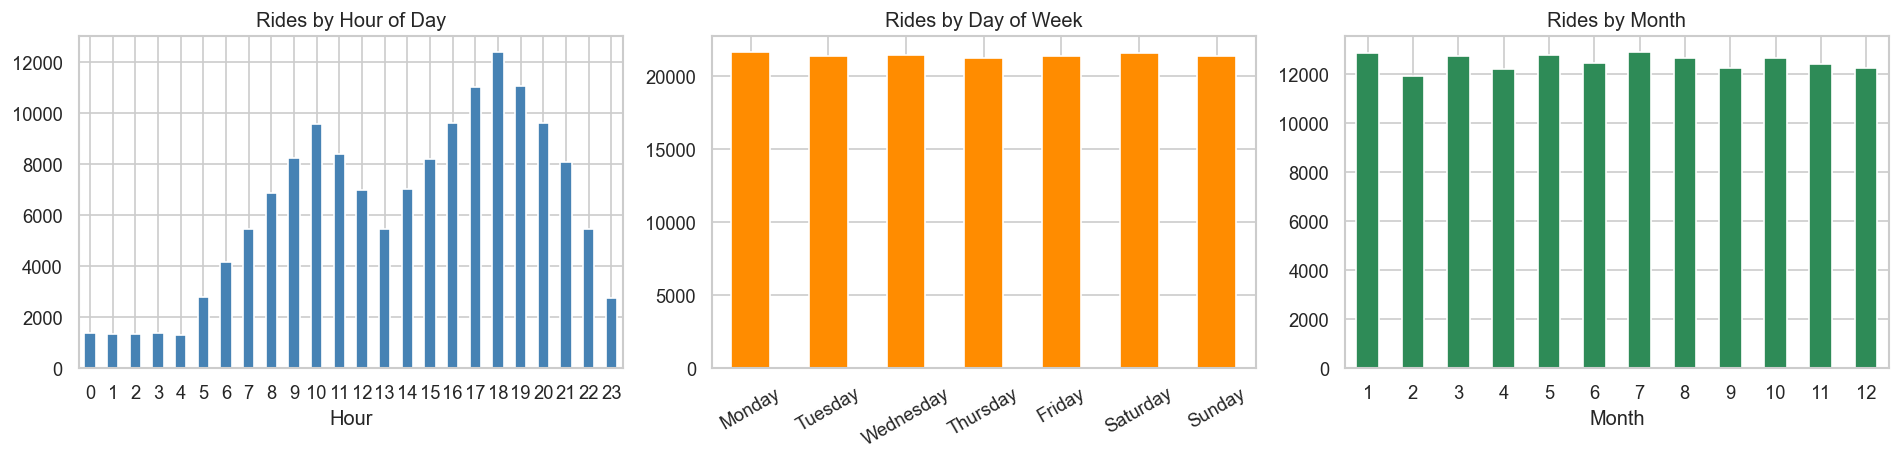

In [38]:
dt = pd.to_datetime(df['Date'] + ' ' + df['Time'])
hourly_rides = dt.dt.hour.value_counts().sort_index()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_rides = dt.dt.day_name().value_counts().reindex(dow_order)
monthly_rides = dt.dt.month.value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
hourly_rides.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rides by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].tick_params(axis='x', rotation=0)

weekly_rides.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Rides by Day of Week')
axes[1].tick_params(axis='x', rotation=30)

monthly_rides.plot(kind='bar', ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Rides by Month')
axes[2].set_xlabel('Month')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

log.add(
    section_id='16_temporal_patterns',
    title='Temporal Patterns',
    cell_type='analysis',
    purpose='Analyze ride volume by hour of day, day of week, and month to identify temporal demand patterns',
    data={
        'hourly': hourly_rides.to_dict(),
        'day_of_week': weekly_rides.to_dict(),
        'monthly': monthly_rides.to_dict(),
    },
)

## 14. Location Distribution

176 unique pickup locations and 176 unique drop locations covering NCR
(Delhi, Gurgaon, Noida). Checking if the distribution is realistic (power-law:
a few hubs dominate) or suspiciously uniform (a signal of synthetic data).

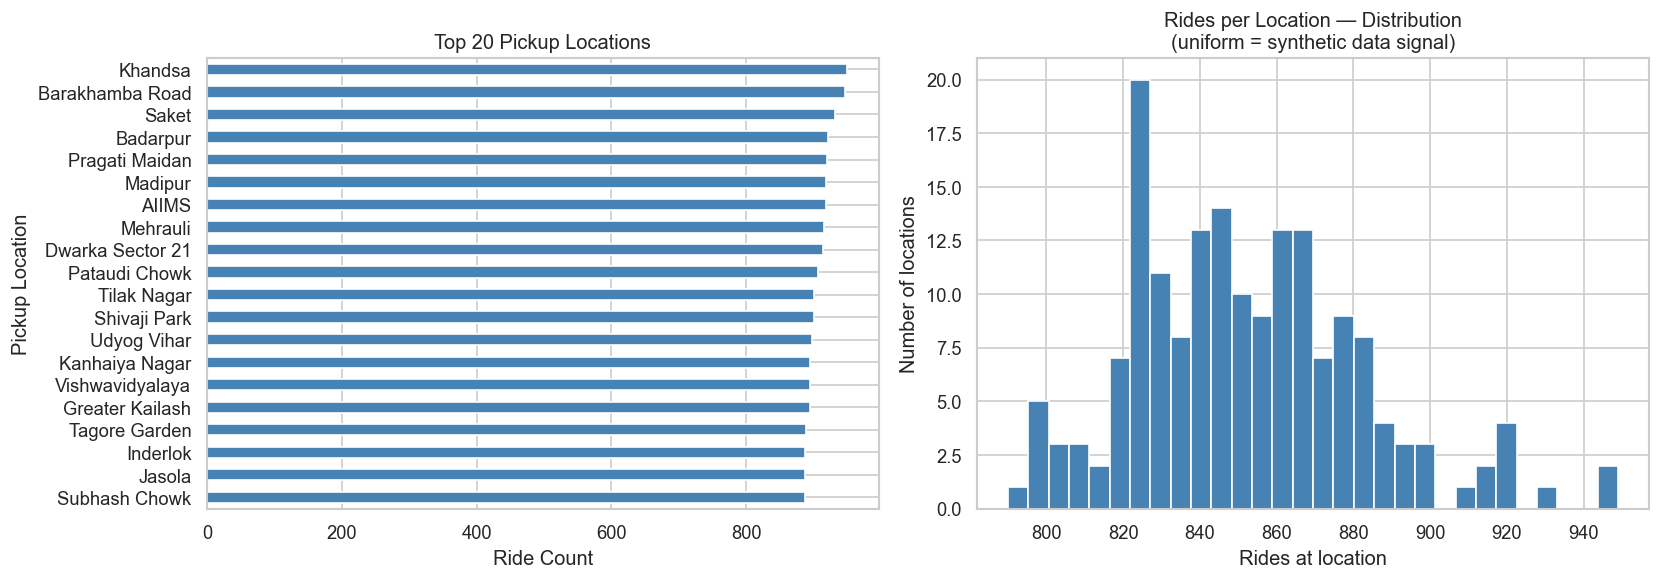

In [39]:
pickup_counts = df['Pickup Location'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pickup_counts.head(20).sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 Pickup Locations')
axes[0].set_xlabel('Ride Count')

axes[1].hist(pickup_counts.values, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Rides per Location — Distribution\n(uniform = synthetic data signal)')
axes[1].set_xlabel('Rides at location')
axes[1].set_ylabel('Number of locations')

plt.tight_layout()
plt.show()

log.add(
    section_id='17_location_distribution',
    title='Location Distribution',
    cell_type='analysis',
    purpose='Examine pickup location frequency to detect power-law vs uniform distribution as a synthetic data signal',
    data={'pickup_top20': pickup_counts.head(20).to_dict()},
)

## 15. Wait Times, Distance & Fare — Relationships

- **VTAT** (Vehicle Time After Trigger): driver travel time to pickup point.
- **CTAT** (Customer Time After Trigger): total customer wait time from booking.

Does waiting longer lower ratings? Does distance predict fare?

/var/folders/1b/v3g60jxd3fl0r7j5mjn_pqd80000gn/T/ipykernel_23536/2766052795.py:21: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/shivanibaskar/Desktop/github/claudecode_for_data_scientists/uber_ride_analytics/experiment_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


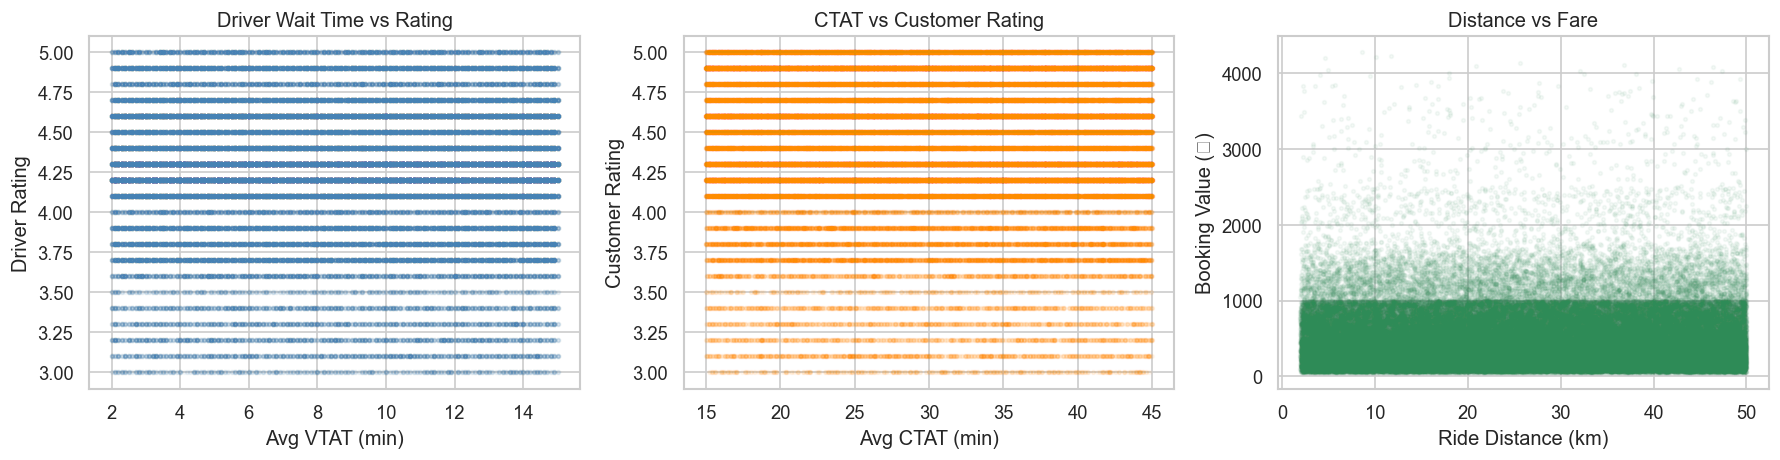

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(completed['Avg VTAT'], completed['Driver Ratings'],
                alpha=0.05, s=5, color='steelblue')
axes[0].set_xlabel('Avg VTAT (min)')
axes[0].set_ylabel('Driver Rating')
axes[0].set_title('Driver Wait Time vs Rating')

axes[1].scatter(completed['Avg CTAT'], completed['Customer Rating'],
                alpha=0.05, s=5, color='darkorange')
axes[1].set_xlabel('Avg CTAT (min)')
axes[1].set_ylabel('Customer Rating')
axes[1].set_title('CTAT vs Customer Rating')

axes[2].scatter(completed['Ride Distance'], completed['Booking Value'],
                alpha=0.05, s=5, color='seagreen')
axes[2].set_xlabel('Ride Distance (km)')
axes[2].set_ylabel('Booking Value (₹)')
axes[2].set_title('Distance vs Fare')

plt.tight_layout()
plt.show()

log.add(
    section_id='18_relationships',
    title='Wait Times, Distance & Fare Relationships',
    cell_type='analysis',
    purpose='Visualize relationships between wait times and ratings, and between ride distance and fare',
    data={},
)

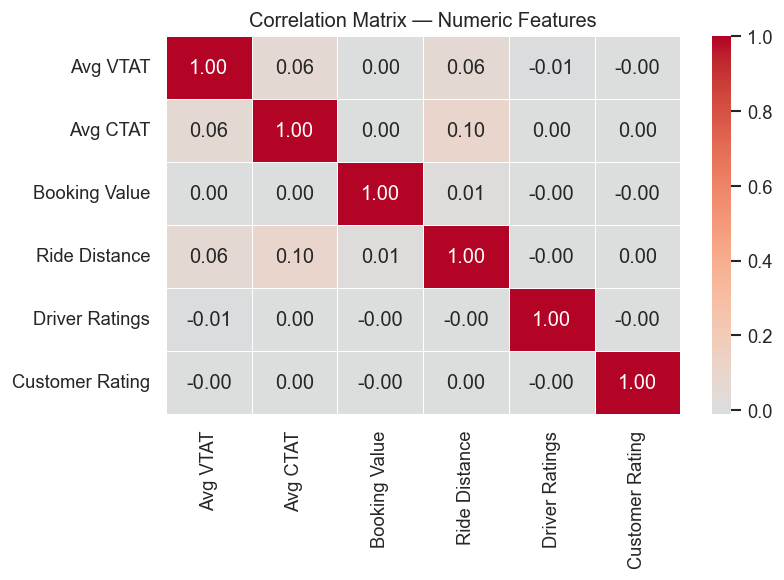

In [41]:
corr_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']
corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

log.add(
    section_id='19_correlation_matrix',
    title='Correlation Matrix',
    cell_type='analysis',
    purpose='Compute pairwise correlations between numeric features to identify linear relationships',
    data=corr_matrix.to_dict(orient='index'),
)

## 16. Hard Caps in the Data

Several numeric columns have suspiciously round maximum (or minimum) values,
suggesting artificial limits — either from data generation or deliberate binning.

In [42]:
caps = [
    ('Avg VTAT',        'max', 20.0),
    ('Avg CTAT',        'max', 45.0),
    ('Ride Distance',   'max', 50.0),
    ('Driver Ratings',  'min',  3.0),
    ('Customer Rating', 'min',  3.0),
]
rows = []
for col, bound, val in caps:
    series = df[col].dropna()
    at_bound = int((series == val).sum())
    rows.append({
        'column': col,
        'bound': bound,
        'value': val,
        'count_at_bound': at_bound,
        '%_of_non_null': round(at_bound / len(series) * 100, 1),
    })
cap_df = pd.DataFrame(rows)

log.add(
    section_id='20_hard_caps',
    title='Hard Caps in the Data',
    cell_type='analysis',
    purpose='Identify artificially capped numeric values that suggest data generation limits or deliberate binning',
    data=cap_df.to_dict(orient='records'),
)
cap_df

,column,bound,value,count_at_bound,%_of_non_null
0,Avg VTAT,max,20.00,38,0.00
1,Avg CTAT,max,45.00,144,0.10
2,Ride Distance,max,50.00,9,0.00
3,Driver Ratings,min,3.00,745,0.80
4,Customer Rating,min,3.00,468,0.50


---
## Save Outputs

In [43]:
log.save(OUTPUT_DIR / 'initial_data_exploration.json')

Saved → outputs/initial_data_exploration.json  (20 sections)
